Running EKF with Corrected Geometry & Lateral Dynamics...


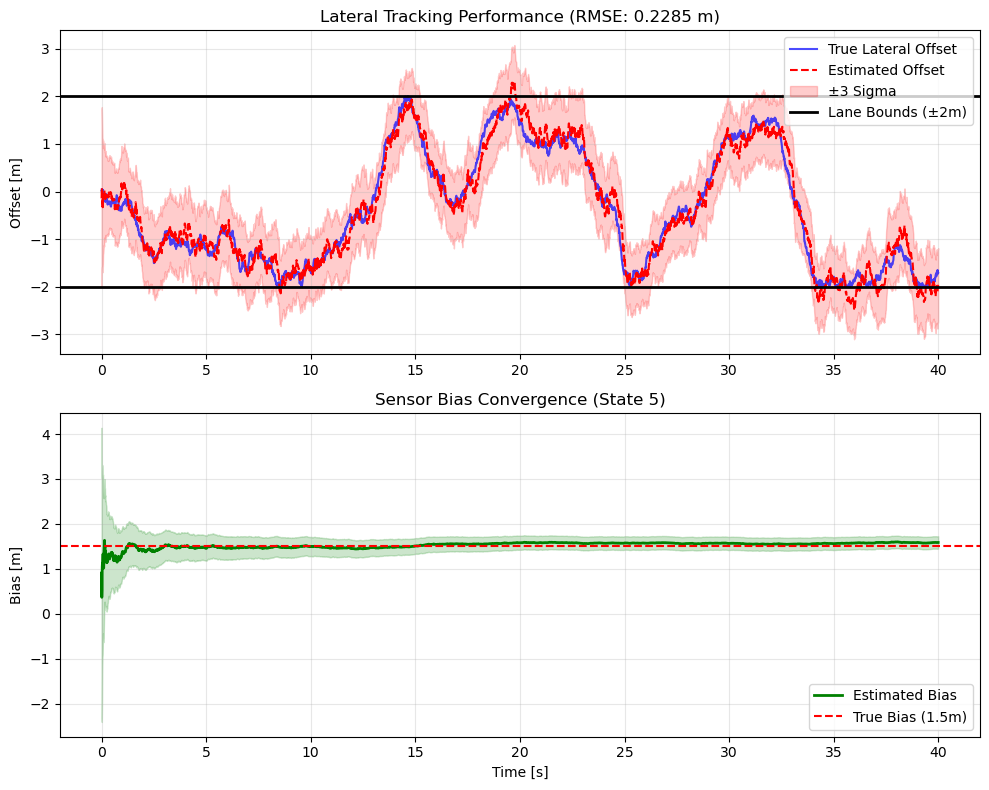

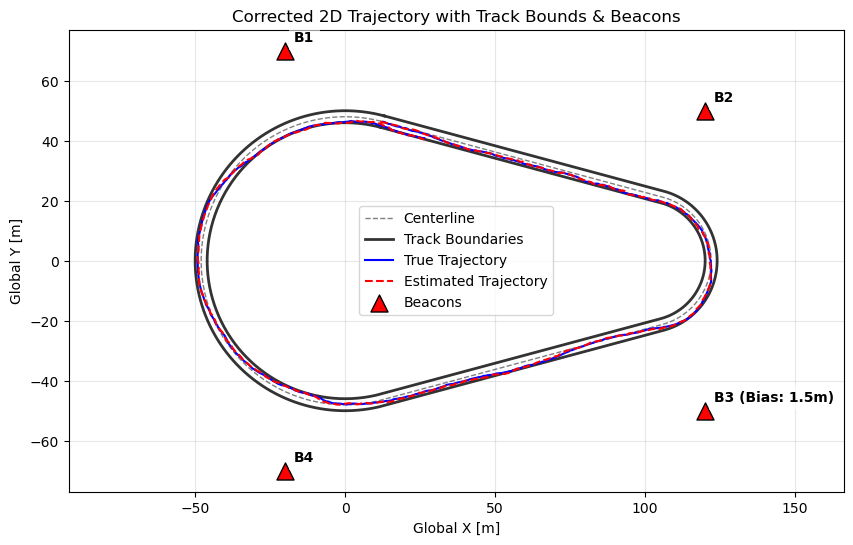

In [5]:
import numpy as np
import casadi as cs
import matplotlib.pyplot as plt
import time

np.random.seed(42)

# ============================================================
# 1. 시뮬레이션 및 시스템 파라미터 셋업
# ============================================================
h_dt = 0.01  
v_target = 10.0
k_vel = 0.1
R_meas_std = 1.5
TRUE_BIAS = 1.5

# 횡방향 동역학 복원력 (OU 프로세스 복구 - 벽타기 현상 해결)
k_damp = 0.5    # 속도 감쇠
k_restore = 0.1 # 중앙 복원력

Q = np.diag([0.001, 0.01, 0.001, 0.01, 1e-6])
R_mat = (R_meas_std**2) * np.eye(4)

x0 = np.array([[0.0], [10.0], [0.0], [0.0], [0.0]])
P0 = np.diag([1.0, 0.5, 0.5, 0.1, 2.0])

# 비콘 4개 직사각형 배치
beacons = np.array([[-20, 70], [120, 50], [120, -50], [-20, -70]])
ny = len(beacons)

# ============================================================
# 2. 복합 트랙 모델 및 야코비안 자동 미분 (CasADi)
# ============================================================
R1, R2, d_centers = 48.0, 22.0, 100.0
sin_alpha = (R1 - R2) / d_centers
alpha = np.arcsin(sin_alpha)

L_str = d_centers * np.cos(alpha)
# [오류 수정 완료] 곡선 호의 길이(Arc length) 계산식 정상화
L_curveB = R2 * (np.pi - 2 * alpha) # 작은 원 (오른쪽)
L_curveA = R1 * (np.pi + 2 * alpha) # 큰 원 (왼쪽)
L_tot = 2 * L_str + L_curveB + L_curveA

P_A_top_x, P_A_top_y = R1 * np.sin(alpha), R1 * np.cos(alpha)
P_B_bot_x, P_B_bot_y = d_centers + R2 * np.sin(alpha), -R2 * np.cos(alpha)

s_sym, vs_sym = cs.MX.sym('s'), cs.MX.sym('vs')
d_sym, vd_sym = cs.MX.sym('d'), cs.MX.sym('vd')
b_sym = cs.MX.sym('b')
state_sym = cs.vertcat(s_sym, vs_sym, d_sym, vd_sym, b_sym)

s_mod = cs.fmod(s_sym, L_tot)

# Segment 1: Top Straight
x1, y1, psi1 = P_A_top_x + s_mod * cs.cos(-alpha), P_A_top_y + s_mod * cs.sin(-alpha), -alpha
# Segment 2: Right Curve
s2 = s_mod - L_str
theta2 = (np.pi/2 - alpha) - s2 / R2
x2, y2, psi2 = d_centers + R2 * cs.cos(theta2), R2 * cs.sin(theta2), theta2 - np.pi/2
# Segment 3: Bottom Straight
s3 = s_mod - (L_str + L_curveB)
x3, y3, psi3 = P_B_bot_x + s3 * cs.cos(-np.pi + alpha), P_B_bot_y + s3 * cs.sin(-np.pi + alpha), -np.pi + alpha
# Segment 4: Left Curve
s4 = s_mod - (2 * L_str + L_curveB)
theta4 = (-np.pi/2 + alpha) - s4 / R1
x4, y4, psi4 = R1 * cs.cos(theta4), R1 * cs.sin(theta4), theta4 - np.pi/2

x_c = cs.if_else(s_mod < L_str, x1, cs.if_else(s_mod < L_str + L_curveB, x2, cs.if_else(s_mod < 2 * L_str + L_curveB, x3, x4)))
y_c = cs.if_else(s_mod < L_str, y1, cs.if_else(s_mod < L_str + L_curveB, y2, cs.if_else(s_mod < 2 * L_str + L_curveB, y3, y4)))
psi_c = cs.if_else(s_mod < L_str, psi1, cs.if_else(s_mod < L_str + L_curveB, psi2, cs.if_else(s_mod < 2 * L_str + L_curveB, psi3, psi4)))

X_global = x_c - d_sym * cs.sin(psi_c)
Y_global = y_c + d_sym * cs.cos(psi_c)

h_list = []
for i in range(ny):
    dist = cs.sqrt((X_global - beacons[i, 0])**2 + (Y_global - beacons[i, 1])**2)
    h_list.append(dist + b_sym if i == 2 else dist)
h_sym = cs.vertcat(*h_list)

calc_global_pos = cs.Function('calc_global_pos', [s_sym, d_sym], [X_global, Y_global])
h_func = cs.Function('h_func', [state_sym], [h_sym])
C_func = cs.Function('C_func', [state_sym], [cs.jacobian(h_sym, state_sym)])

# ============================================================
# 3. 파이썬 EKF 코어 함수 (복원력 추가)
# ============================================================
def f_discrete(x, dt):
    s, v_s, d, v_d, b = x.flatten()
    return np.array([
        [s + v_s * dt],
        [v_s + k_vel * (v_target - v_s) * dt],
        [d + v_d * dt],
        [v_d - (k_damp * v_d + k_restore * d) * dt], # 중앙 복원력(OU) 반영
        [b]
    ])

def get_A_matrix(x, dt):
    A = np.eye(5)
    A[0, 1] = dt
    A[1, 1] = 1 - k_vel * dt
    A[2, 3] = dt
    A[3, 2] = -k_restore * dt
    A[3, 3] = 1 - k_damp * dt
    return A

# ============================================================
# 4. EKF 메인 루프 
# ============================================================
n_steps = 4000
x_true = x0.copy()
x_est = x0.copy()
P_est = P0.copy()

true_history, est_history, P_history = [], [], []

print("Running EKF with Corrected Geometry & Lateral Dynamics...")
start_exec = time.time()

for k in range(n_steps):
    # --- 1. True Plant ---
    w_true = np.random.multivariate_normal(np.zeros(5), Q).reshape(-1, 1)
    w_true[4, 0] = 0
    x_true = f_discrete(x_true, h_dt) + w_true
    x_true[4, 0] = TRUE_BIAS
    
    # [수정] 벽에 닿으면 튕겨나가는 Bouncing 로직 부활
    if x_true[2, 0] > 2.0: 
        x_true[2, 0] = 2.0
        x_true[3, 0] *= -0.5
    elif x_true[2, 0] < -2.0: 
        x_true[2, 0] = -2.0
        x_true[3, 0] *= -0.5

    # --- 2. Measurement ---
    z_real = np.array(h_func(x_true)).reshape(-1, 1) + np.random.normal(0, R_meas_std, (ny, 1))

    # --- 3. EKF Prediction ---
    x_pred = f_discrete(x_est, h_dt)
    A_k = get_A_matrix(x_est, h_dt)
    P_pred = A_k @ P_est @ A_k.T + Q
    P_pred = (P_pred + P_pred.T) / 2.0

    # --- 4. EKF Correction ---
    C_k = np.array(C_func(x_pred)).astype(float)
    z_hat = np.array(h_func(x_pred)).reshape(-1, 1)
    
    innovation = z_real - z_hat
    S = C_k @ P_pred @ C_k.T + R_mat
    K = P_pred @ C_k.T @ np.linalg.inv(S)
    
    x_est = x_pred + K @ innovation
    P_est = (np.eye(5) - K @ C_k) @ P_pred
    P_est = (P_est + P_est.T) / 2.0

    true_history.append(x_true.flatten())
    est_history.append(x_est.flatten())
    P_history.append(P_est.copy())

exec_time = (time.time() - start_exec) / n_steps

# ============================================================
# 5. RMSE & 플롯
# ============================================================
true_history = np.array(true_history)
est_history = np.array(est_history)
P_history = np.array(P_history)
t_axis = np.arange(n_steps) * h_dt

rmse_s = np.sqrt(np.mean((true_history[100:, 0] - est_history[100:, 0])**2))
rmse_d = np.sqrt(np.mean((true_history[100:, 2] - est_history[100:, 2])**2))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Lateral Tracking Plot
sigma_d = np.sqrt(P_history[:, 2, 2])
ax1.plot(t_axis, true_history[:, 2], 'b-', label='True Lateral Offset', alpha=0.7)
ax1.plot(t_axis, est_history[:, 2], 'r--', label='Estimated Offset')
ax1.fill_between(t_axis, est_history[:, 2] - 3*sigma_d, est_history[:, 2] + 3*sigma_d, color='red', alpha=0.2, label='±3 Sigma')
ax1.axhline(2.0, color='k', linestyle='-', linewidth=2, label='Lane Bounds (±2m)')
ax1.axhline(-2.0, color='k', linestyle='-', linewidth=2)
ax1.set_title(f'Lateral Tracking Performance (RMSE: {rmse_d:.4f} m)')
ax1.set_ylabel('Offset [m]')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Bias Plot
sigma_b = np.sqrt(P_history[:, 4, 4])
ax2.plot(t_axis, est_history[:, 4], 'g-', linewidth=2, label='Estimated Bias')
ax2.fill_between(t_axis, est_history[:, 4] - 3*sigma_b, est_history[:, 4] + 3*sigma_b, color='green', alpha=0.2)
ax2.axhline(TRUE_BIAS, color='r', linestyle='--', label='True Bias (1.5m)')
ax2.set_title('Sensor Bias Convergence (State 5)')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Bias [m]')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 2D Trajectory Plot (완벽한 캡슐 형태 트랙)
plt.figure(figsize=(10, 6))

s_vals = np.linspace(0, L_tot, 1000) # 고해상도 렌더링
X_c, Y_c, X_in, Y_in, X_out, Y_out = [], [], [], [], [], []

for s_val in s_vals:
    xc, yc = calc_global_pos(float(s_val), 0.0) 
    xin, yin = calc_global_pos(float(s_val), -2.0) 
    xout, yout = calc_global_pos(float(s_val), 2.0) 
    X_c.append(float(xc)); Y_c.append(float(yc))
    X_in.append(float(xin)); Y_in.append(float(yin))
    X_out.append(float(xout)); Y_out.append(float(yout))

plt.plot(X_c, Y_c, 'k--', linewidth=1, alpha=0.5, label='Centerline')
plt.plot(X_in, Y_in, 'k-', linewidth=2, alpha=0.8, label='Track Boundaries')
plt.plot(X_out, Y_out, 'k-', linewidth=2, alpha=0.8)

# 궤적 (5스텝 다운샘플링)
X_true_arr, Y_true_arr, X_est_arr, Y_est_arr = [], [], [], []
for i in range(0, n_steps, 5):
    xt, yt = calc_global_pos(float(true_history[i, 0]), float(true_history[i, 2]))
    xe, ye = calc_global_pos(float(est_history[i, 0]), float(est_history[i, 2]))
    X_true_arr.append(float(xt)); Y_true_arr.append(float(yt))
    X_est_arr.append(float(xe)); Y_est_arr.append(float(ye))

plt.plot(X_true_arr, Y_true_arr, 'b-', linewidth=1.5, label='True Trajectory')
plt.plot(X_est_arr, Y_est_arr, 'r--', linewidth=1.5, label='Estimated Trajectory')

plt.scatter(beacons[:, 0], beacons[:, 1], c='red', marker='^', s=150, edgecolors='black', label='Beacons')
for i, (bx, by) in enumerate(beacons):
    label = f'B{i+1} (Bias: 1.5m)' if i == 2 else f'B{i+1}'
    plt.text(bx + 3, by + 3, label, fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.title('Corrected 2D Trajectory with Track Bounds & Beacons')
plt.xlabel('Global X [m]')
plt.ylabel('Global Y [m]')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()